# Neural Density Comparison

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

In [2]:
plt.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           16,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelsize":      16,
    "legend.fontsize":     12,
    "xtick.labelsize":     12,
    "ytick.labelsize":     12,
})

In [3]:
results = xr.load_datatree("../outputs/compare_densities/density_comparison.nc")

dt_wald = results["wald"]

dt_values = [0.05, 0.005, 0.0005] 

dt_crdm = xr.concat(
    [
        results[f"crdm_dt{dt}"].ds.expand_dims(dt=[dt])
        for dt in dt_values    
    ],
    dim="dt"
)

## Timing

In [4]:
time_unit_div = 1e-3

df_timing = pd.DataFrame({
    "Model": (["Wald"] + ["Conflict"] * 3) * 2,
    "dt": ([""] + dt_values) * 2,
    "Method": ["Neural"] * 4 + ["Reference"] * 4,
    "Median": [
        dt_wald.time_neural_per_param.median().to_numpy() / time_unit_div
    ] + [
        results[f"crdm_dt{dt}"].time_neural_per_param.median().to_numpy() / time_unit_div for dt in dt_values
    ] + [
        dt_wald.time_ref_per_param.median().to_numpy() / time_unit_div
    ] + [
        results[f"crdm_dt{dt}"].time_ref_per_param.median().to_numpy() / time_unit_div for dt in dt_values
    ],
    "SD": [
        dt_wald.time_neural_per_param.std().to_numpy() / time_unit_div
    ] + [
        results[f"crdm_dt{dt}"].time_neural_per_param.std().to_numpy() / time_unit_div for dt in dt_values
    ] + [
        dt_wald.time_ref_per_param.std().to_numpy() / time_unit_div
    ] + [
        results[f"crdm_dt{dt}"].time_ref_per_param.std().to_numpy() / time_unit_div for dt in dt_values
    ],
})

df_timing_wide = df_timing.pivot(index=["Model", "dt"], columns="Method")
df_timing_wide = df_timing_wide.swaplevel(axis=1).sort_index(axis=1)
df_timing_wide[("", "Ratio")] = df_timing_wide[("Reference", "Median")] / df_timing_wide[("Neural", "Median")]
print(df_timing_wide.sort_index(ascending=False).to_latex(float_format="%.3f"))
# df_timing_wide

\begin{tabular}{llrrrrr}
\toprule
 & Method & \multicolumn{2}{r}{Neural} & \multicolumn{2}{r}{Reference} &  \\
 &  & Median & SD & Median & SD & Ratio \\
Model & dt &  &  &  &  &  \\
\midrule
Wald &  & 0.169 & 0.015 & 0.072 & 0.005 & 0.423 \\
\cline{1-7}
\multirow[t]{3}{*}{Conflict} & 0.050000 & 0.186 & 0.008 & 0.916 & 0.009 & 4.922 \\
 & 0.005000 & 0.192 & 0.007 & 7.972 & 0.021 & 41.532 \\
 & 0.000500 & 0.196 & 0.021 & 99.428 & 0.235 & 506.378 \\
\cline{1-7}
\bottomrule
\end{tabular}



In [5]:
df_timing_wide.sort_index(ascending=False)

Method             Neural            Reference                      
                   Median        SD     Median        SD       Ratio
Model    dt                                                         
Wald             0.169222  0.015460   0.071662  0.004612    0.423476
Conflict 0.05    0.186016  0.008233   0.915591  0.009365    4.922101
         0.005   0.191948  0.007113   7.972012  0.021242   41.532062
         0.0005  0.196352  0.021405  99.428238  0.234618  506.378367

In [ ]:
fig, axes = plt.subplots(
    1, 2, figsize=(10, 4.5), sharey=True,
    gridspec_kw={"width_ratios": [1, 3]},
)

methods = ["Neural", "Reference"]
_colors = sns.color_palette("Dark2", 3)
palette = {"Neural": _colors[0], "Analytic": _colors[1], "Numerical": _colors[2]}


def grouped_bar(ax, data, x_order, xticklabels, title, xlabel, method_labels):
    width = 0.8 / len(methods)
    x = np.arange(len(x_order))
    for i, method in enumerate(methods):
        sub = data[data["Method"] == method].set_index("dt").loc[x_order]
        label = method_labels[method]
        ax.bar(
            x + (i - (len(methods) - 1) / 2) * width,
            sub["Median"], width,
            yerr=sub["SD"], capsize=3,
            label=label, color=palette[label],
        )
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()


grouped_bar(
    axes[0],
    df_timing[df_timing["Model"] == "Wald"],
    x_order=[""], xticklabels=[""],
    title="Wald", xlabel="",
    method_labels={"Neural": "Neural", "Reference": "Analytic"},
)

grouped_bar(
    axes[1],
    df_timing[df_timing["Model"] == "Conflict"],
    x_order=dt_values, xticklabels=[str(dt) for dt in dt_values],
    title="Conflict", xlabel=r"$dt$",
    method_labels={"Neural": "Neural", "Reference": "Numerical"},
)

for ax in axes:
    ax.set_yscale("log")

axes[0].set_ylabel("Median evaluation\ntime (ms)")

fig.tight_layout()
fig.savefig("densities/timing_comparison.png")

## RDM

In [6]:
df_wald_join = (dt_wald.mad_cdf.to_dataframe()
    .merge(dt_wald.mad_pdf.to_dataframe())
    .melt(id_vars=["v", "s", "b"], var_name="type", value_name="mad")
    .melt(id_vars=["type", "mad"], var_name="param", value_name="param_value")
)

df_wald_join["type"] = df_wald_join["type"].replace({
    "mad_cdf": "CDF",
    "mad_pdf": "PDF",
})

df_wald_join["param"] = df_wald_join["param"].replace({
    "v": r"$\nu$",
    "s": r"$\sigma$",
    "b": r"$b$",
})

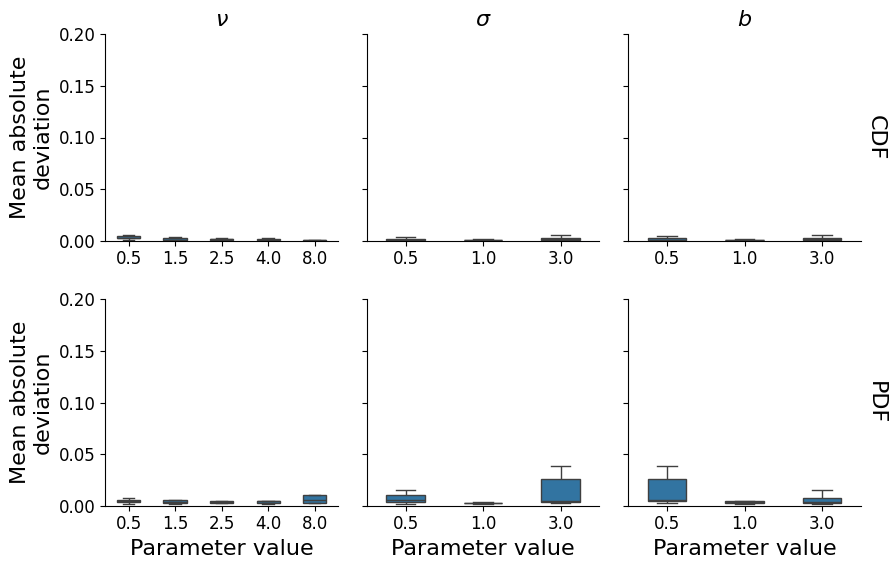

In [7]:
g = sns.FacetGrid(df_wald_join, row="type", col="param", sharex=False, margin_titles=True, ylim=(0, 0.2))
g.map_dataframe(sns.boxplot, x="param_value", y="mad", width=0.5, flierprops={"marker": ""})

# g.refline(y=0.0)

g.set_xlabels(label="Parameter value")
g.set_ylabels(label="Mean absolute\ndeviation")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

g.savefig("densities/mad_rdm.png")

## CRDM

In [8]:
df_crdm_join = (dt_crdm.mad_cdf.to_dataframe().reset_index()
    .merge(dt_crdm.mad_pdf.to_dataframe().reset_index())
    .drop(["param"], axis=1)
    .melt(id_vars=["dt", "v_c", "amp", "tau", "s", "b"], var_name="type", value_name="mad")
    .melt(id_vars=["dt", "type", "mad"], var_name="param", value_name="param_value")
)

df_crdm_join["type"] = df_crdm_join["type"].replace({
    "mad_cdf": "CDF",
    "mad_pdf": "PDF",
})

df_crdm_join["param"] = df_crdm_join["param"].replace({
    "v_c": r"$\nu$",
    "amp": r"$\zeta$",
    "tau": r"$\tau$",
    "s": r"$\sigma$",
    "b": r"$b$",
})

df_crdm_join["dt"] = df_crdm_join["dt"].astype(str)

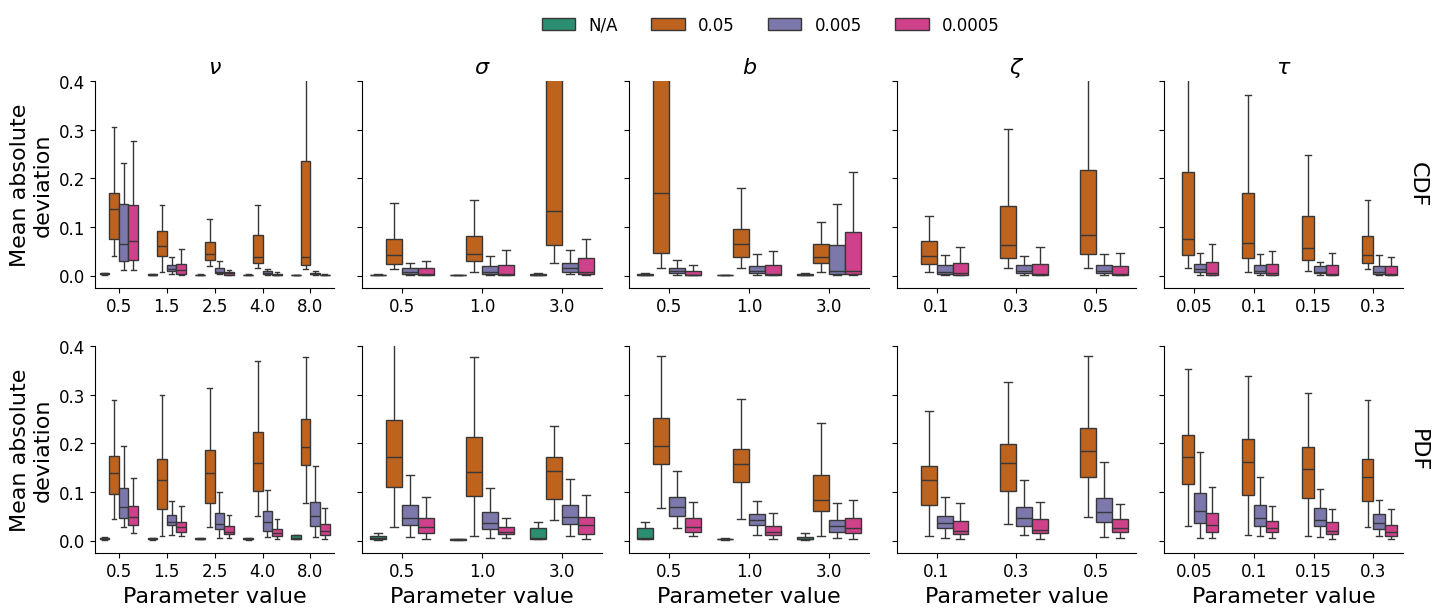

In [16]:
dt_order = [str(dt) for dt in ["N/A"] + dt_values]

df_wald_join["dt"] = "N/A"

g = sns.FacetGrid(pd.concat([df_wald_join, df_crdm_join]), row="type", col="param", sharex=False, margin_titles=True, ylim=(-0.025, 0.4))
g.map_dataframe(sns.boxplot, x="param_value", y="mad", hue="dt", hue_order=dt_order, palette="Dark2", width=0.8, flierprops={"marker": ""})

# g.refline(y=0.0)

g.set_xlabels(label="Parameter value")
g.set_ylabels(label="Mean absolute\ndeviation")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

g.add_legend(loc="upper center",
    ncols=4,
    bbox_to_anchor=(0.4, 1.05))

g.savefig("densities/mad_rdm_crdm.png")